In [1]:
!pip install opencv_python
!pip install natsort

fish: Unknown command: pip
fish: 
pip install opencv_python
^~^
fish: Unknown command: pip
fish: 
pip install natsort
^~^


In [2]:
import cv2
import pickle
from natsort import natsorted
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import davies_bouldin_score, silhouette_score


In [3]:
data_fname = 'data.pickle'

In [4]:
with open(data_fname, 'rb') as handle:
    data = pickle.load(handle)

In [5]:
natsorted(data.keys())

['0.pickle',
 '1.pickle',
 '2.pickle',
 '3.pickle',
 '4.pickle',
 '5.pickle',
 '6.pickle',
 '7.pickle',
 '8.pickle',
 '9.pickle',
 '10.pickle',
 '11.pickle',
 '12.pickle',
 '13.pickle',
 '14.pickle',
 '15.pickle',
 '16.pickle',
 '17.pickle',
 '18.pickle',
 '19.pickle',
 '20.pickle',
 '21.pickle',
 '22.pickle',
 '23.pickle',
 '24.pickle',
 '25.pickle',
 '26.pickle',
 '27.pickle',
 '28.pickle',
 '29.pickle',
 '30.pickle',
 '31.pickle',
 '32.pickle',
 '33.pickle',
 '34.pickle',
 '35.pickle',
 '36.pickle',
 '37.pickle']

# Визуализация

Можно заметить, что распознанные границы объектов не всегда четко определены:

- присутствует перспектива на изображении, из-за чего силуэт полок бывает не строго горизонтальный, а изменяет направление на одном фото:
    - примеры изображений: 0, 3, 5, 17, 18, 22, 25, 30, 33;
- изображение может не охватывать целиком весь стилаж:
    - примеры изображений: 4, 11;
- встречаются наслоения границ объектов друг на друга:
    - примеры изображений: 0, 9, 21, 29;
- встречаются явно ошибочные хаотично-распознанные изображения:
    - примеры изображений: 7;
- объекты, которые вплотную располагаются скорее всего находятся на одной полке, но в 2 ряда:
    - примеры изображений: 8, 19, 21, 27, 30, 34, 35, 36;
- есть ситуации, когда объекты с разных рядов распознаются как один:
    - примеры изображений: 20;
- на полках могут встречаться пропуски товара:
    - примеры изображений: 12, 13, 26, 28.


In [6]:
id = 2

fname = f'{id}.pickle'

img_size = data[fname]['img_size']
bboxes = data[fname]['bboxes']

In [7]:
img = np.zeros(img_size, dtype=np.uint8)
img.fill(255)

for x1, y1, x2, y2 in bboxes:
    img = cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 0), 2)

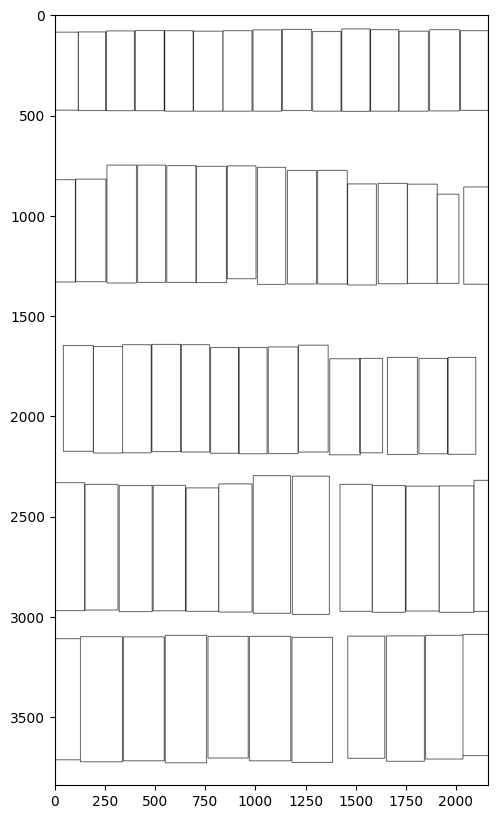

In [8]:
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.show()

# Задание

Написать функцию divide_by_shelfs, принимающую на вход bboxes, img_size и возвращающую для каждого прямоугольника из bboxes номер полки. Нумерация сверху-вниз с нуля.

## Выполнение

Для начала попробуем наивную модель кластеризации через K-Mean для y-координат центров bbox. Оказывается, что это даёт довольно хороший результат, хотя инференс страдает на изображениях с перспективой.

В голову приходит идея как-то учесть перспективу с помощью литейного преобразования: или сделать предобработку данных линейным преобразованием на матрицах для исправления перспективы, или построить линейную регрессию для границ каждого кластера (полки), тем самым сегментировав изображение для коррекции выбросов.

Остановимся на втором варианте как наиболее простом. Всё так же используем K-Mean, но подбираем количество кластеров автоматически через поиск "лучшего" по приросту информативности числа кластеров. И после нескольких итераций улучшения путем подбора порога для кластеризации получаем отличный результат на всех входных данных.

In [9]:
def divide_by_shelfs(bboxes, img_size):
    if not bboxes:
        return np.array([])

    centers_y = np.array([(y1 + y2) / 2 for x1, y1, x2, y2 in bboxes]).reshape(-1, 1)

    # Automatic Shelf Detection
    max_k = min(9, len(bboxes) + 1)
    inertias = []
    for k in range(1, max_k):
        km = KMeans(n_clusters=k, random_state=0, n_init="auto").fit(centers_y)
        inertias.append(km.inertia_)

    # Heuristic: find n where we capture significant variance - Elbow Method
    # Decreased gain threshold to 2% to be more sensitive to existing shelves
    threashold = 0.02
    n_shelves = 1
    if len(inertias) > 1:
        initial_inertia = inertias[0]
        for k_idx in range(1, len(inertias)):
            gain = inertias[k_idx - 1] - inertias[k_idx]
            if gain < initial_inertia * threashold:
                n_shelves = k_idx
                break
            n_shelves = k_idx + 1

    # Perform clustering with detected count
    kmeans = KMeans(n_clusters=n_shelves, random_state=0, n_init="auto")
    initial_labels = kmeans.fit_predict(centers_y)

    # Sort clusters top-to-bottom
    cluster_means = [centers_y[initial_labels == i].mean() for i in range(n_shelves)]
    sorted_cluster_indices = np.argsort(cluster_means)

    # Fit linear models for perspective tilt
    shelf_models = []
    for idx in sorted_cluster_indices:
        mask = initial_labels == idx
        coords = np.array(
            [
                [(x1 + x2) / 2, (y1 + y2) / 2]
                for i, (x1, y1, x2, y2) in enumerate(bboxes)
                if mask[i]
            ]
        )
        X, Y = coords[:, 0:1], coords[:, 1:2]

        if len(X) > 1:
            model = LinearRegression().fit(X, Y)
        else:
            model = LinearRegression()
            model.coef_ = np.array([[0.0]])
            model.intercept_ = Y[0]
        shelf_models.append(model)

    labels = []
    for x1, y1, x2, y2 in bboxes:
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        predictions = [m.predict([[cx]])[0][0] for m in shelf_models]
        labels.append(np.argmin(np.abs(np.array(predictions) - cy)))

    return np.array(labels)

In [ ]:
def visualize_perspective_shelves(bboxes, img_size, image_id):
    labels = divide_by_shelfs(bboxes, img_size)

    img = np.full((img_size[0], img_size[1], 3), 255, dtype=np.uint8)
    colors = plt.colormaps.get_cmap("tab10")

    plt.figure(figsize=(12, 8))

    for i, bbox in enumerate(bboxes):
        x1, y1, x2, y2 = bbox
        lbl = labels[i]
        c = colors(lbl % 10)[:3]
        cv2.rectangle(img, (x1, y1), (x2, y2), [int(chan * 255) for chan in c[::-1]], 3)
        plt.text(x1, y1 - 10, f"S{lbl}", color=c, fontsize=9, weight="bold")

    for lbl in np.unique(labels):
        mask = labels == lbl
        sub_bboxes = np.array(bboxes)[mask]
        X_vals = (sub_bboxes[:, 0] + sub_bboxes[:, 2]) / 2
        Y_vals = (sub_bboxes[:, 1] + sub_bboxes[:, 3]) / 2

        if len(X_vals) > 1:
            z = np.polyfit(X_vals, Y_vals, 1)
            p = np.poly1d(z)
            x_range = np.linspace(0, img_size[1], 100)
            plt.plot(
                x_range,
                p(x_range),
                color=colors(lbl % 10),
                linestyle="--",
                linewidth=2,
                alpha=0.8,
            )

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Perspective-Aware Shelf Fitting - Image {image_id}")
    plt.axis("off")
    plt.show()


# Visualize examples known for perspective issues

pics = []
# pics = [17, 22, 25, 5, 3] # perspective leads to silhuette and davies-bouldin worse score
# pics = [7, 35, 21, 1, 18, 34, 5] # multi-layer shelves and bad recognized items leads to worse perspective error


for test_id in pics:
    fn = f"{test_id}.pickle"
    if fn in data:
        visualize_perspective_shelves(data[fn]["bboxes"], data[fn]["img_size"], test_id)

In [12]:
def evaluate_shelf_clustering(bboxes, labels):
    if len(np.unique(labels)) < 2:
        return None, None

    centers_x = np.array([(x1 + x2) / 2 for x1, y1, x2, y2 in bboxes]).reshape(-1, 1)
    centers_y = np.array([(y1 + y2) / 2 for x1, y1, x2, y2 in bboxes]).reshape(-1, 1)


    sil = silhouette_score(centers_y, labels)
    db_index = davies_bouldin_score(centers_y, labels)

    total_abs_error = 0
    for lbl in np.unique(labels):
        mask = (labels == lbl)
        X_sub = centers_x[mask]
        Y_sub = centers_y[mask]

        model = LinearRegression().fit(X_sub, Y_sub)
        preds = model.predict(X_sub)
        total_abs_error += np.sum(np.abs(Y_sub - preds))
            
    mean_slope_mae = total_abs_error / len(bboxes)

    return sil, db_index, mean_slope_mae


results = []

for fname in natsorted(data.keys()):
    content = data[fname]
    bboxes = content["bboxes"]
    img_size = content["img_size"]

    labels = divide_by_shelfs(bboxes, img_size)
    sil, db, mae = evaluate_shelf_clustering(bboxes, labels)

    results.append({
        "filename": fname, 
        "silhouette": sil, 
        "davies_bouldin": db,
        "slope_mae": mae
    })


df_metrics = pd.DataFrame(results)

display(df_metrics[["silhouette", "davies_bouldin", "slope_mae"]].mean().to_frame("Average"))

print("Images with the lowest Silhouette scores (potential issues):")
display(df_metrics.sort_values("silhouette", ascending=True).head(7))

print("Images with the highest Davies-Bouldin scores (potential issues):")
display(df_metrics.sort_values("davies_bouldin", ascending=False).head(7))

print("Images with the most slope (perspective) error in pixels (Highest MAE):")
display(df_metrics.sort_values("slope_mae", ascending=False).head(7))

,Average
silhouette,0.896388
davies_bouldin,0.142800
slope_mae,28.284892


Images with the lowest Silhouette scores (potential issues):


,filename,silhouette,davies_bouldin,slope_mae
17,17.pickle,0.736986,0.360269,2.093997
22,22.pickle,0.737123,0.359481,2.800616
25,25.pickle,0.739328,0.374303,3.357011
5,5.pickle,0.761920,0.307391,54.148147
3,3.pickle,0.831322,0.249524,13.578164
18,18.pickle,0.831768,0.231589,62.029977
7,7.pickle,0.832193,0.224156,104.726713


Images with the highest Davies-Bouldin scores (potential issues):


,filename,silhouette,davies_bouldin,slope_mae
25,25.pickle,0.739328,0.374303,3.357011
17,17.pickle,0.736986,0.360269,2.093997
22,22.pickle,0.737123,0.359481,2.800616
5,5.pickle,0.761920,0.307391,54.148147
3,3.pickle,0.831322,0.249524,13.578164
18,18.pickle,0.831768,0.231589,62.029977
7,7.pickle,0.832193,0.224156,104.726713


Images with the most slope (perspective) error in pixels (Highest MAE):


,filename,silhouette,davies_bouldin,slope_mae
7,7.pickle,0.832193,0.224156,104.726713
35,35.pickle,0.854736,0.187054,81.116981
27,27.pickle,0.883494,0.157997,67.210644
1,1.pickle,0.900494,0.148438,65.600128
18,18.pickle,0.831768,0.231589,62.029977
34,34.pickle,0.886889,0.142033,54.836081
5,5.pickle,0.761920,0.307391,54.148147


Перспектива на фото приводит к ухудшению силуэта и качества по методу Дэвиса-Боулдина.

А многослойные полки и плохо распознаваемые предметы приводят к большей ошибке в определении перспективы и определению границ полки, тем не менее не слишком сильно - в среднем 28 px.

Ниже качество модели на снимках с искажениями - с худшим качеством по всем метрикам примерно одни и те же изображения.

Для интереса попросил джарвиса исправить перспективу, чтобы лучше оценить качество кластеризации

In [15]:
def correct_perspective_per_shelf(bboxes, labels):
    """
    Flattens tilted shelves by shifting bounding box coordinates 
    to a horizontal plane based on linear regression per shelf.
    """
    if not bboxes or len(np.unique(labels)) < 1:
        return bboxes
    
    corrected_bboxes = list(bboxes)
    for lbl in np.unique(labels):
        mask = (labels == lbl)
        indices = np.where(mask)[0]
        if len(indices) < 2: 
            continue
            
        sub_bboxes = np.array(bboxes)[mask]
        # Calculate centers
        cx = (sub_bboxes[:, 0] + sub_bboxes[:, 2]) / 2
        cy = (sub_bboxes[:, 1] + sub_bboxes[:, 3]) / 2
        
        # Fit line to shelf tilt
        model = LinearRegression().fit(cx.reshape(-1, 1), cy)
        intercept = model.intercept_
        
        # Shift each bbox in the shelf to the intercept (the 'flat' height)
        for idx in indices:
            x1, y1, x2, y2 = bboxes[idx]
            bcx = (x1 + x2) / 2
            # Difference between where the shelf center is at this X and the baseline intercept
            offset = intercept - model.predict([[bcx]])[0]
            corrected_bboxes[idx] = (x1, int(y1 + offset), x2, int(y2 + offset))
            
    return corrected_bboxes

Full Statistics: Change per Image


,filename,Sil_Orig,Sil_Corr,Sil_Diff,DB_Orig,DB_Corr,DB_Diff
0,0.pickle,0.857638,0.949363,0.091725,0.207828,0.063441,-0.144387
1,1.pickle,0.900494,0.904730,0.004236,0.148438,0.146976,-0.001462
2,2.pickle,0.981282,0.986306,0.005025,0.033031,0.021987,-0.011044
3,3.pickle,0.831322,0.972285,0.140962,0.249524,0.044480,-0.205043
4,4.pickle,0.905840,0.921195,0.015355,0.132621,0.129652,-0.002969
5,5.pickle,0.761920,0.917876,0.155956,0.307391,0.116485,-0.190905
6,6.pickle,0.894885,0.901035,0.006149,0.148026,0.144748,-0.003279
7,7.pickle,0.832193,0.838038,0.005844,0.224156,0.212436,-0.011720
8,8.pickle,0.886881,0.895114,0.008233,0.151218,0.150124,-0.001094
9,9.pickle,0.881308,0.917179,0.035871,0.149040,0.118566,-0.030474


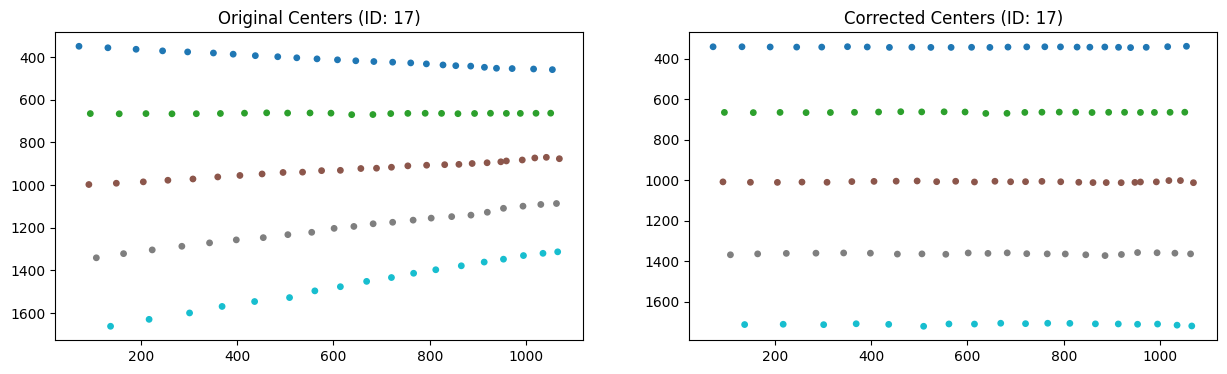

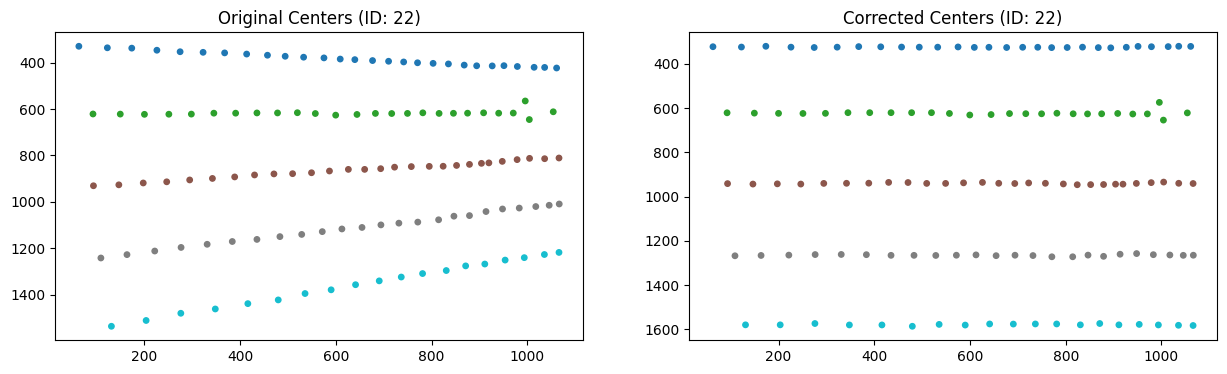

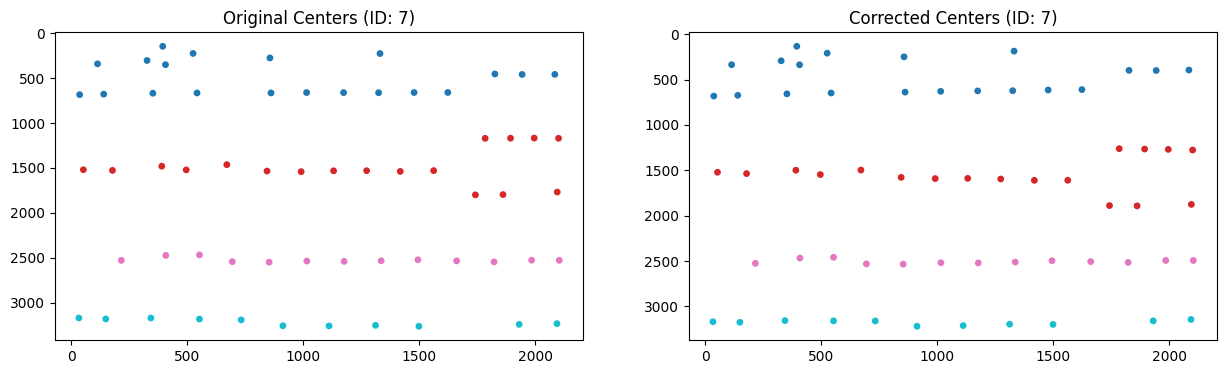

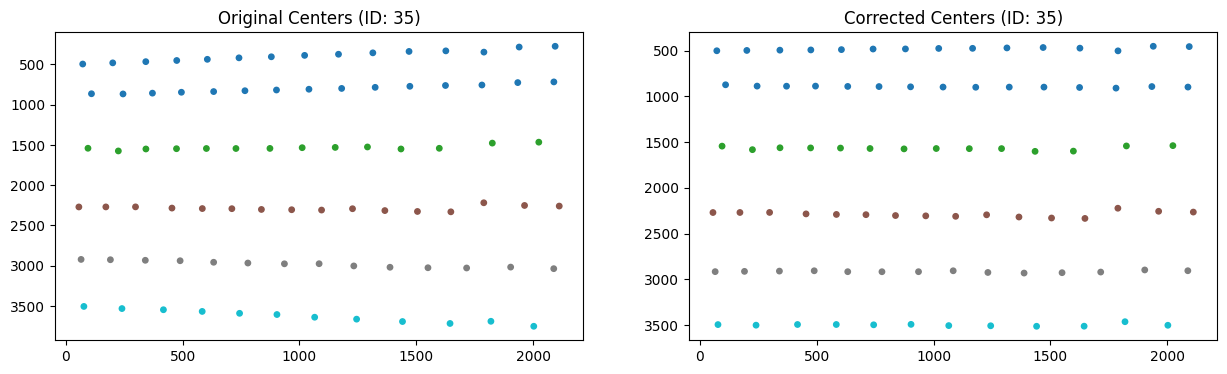

In [21]:
# 1. Calculation logic
all_results = []
for fname in natsorted(data.keys()):
    content = data[fname]
    bboxes, img_size = content["bboxes"], content["img_size"]
    if not bboxes:
        continue

    labels = divide_by_shelfs(bboxes, img_size)
    sil_orig, db_orig, mae_orig = evaluate_shelf_clustering(bboxes, labels)

    corr_bboxes = correct_perspective_per_shelf(bboxes, labels)
    sil_corr, db_corr, mae_corr = evaluate_shelf_clustering(corr_bboxes, labels)

    all_results.append(
        {
            "filename": fname,
            "Sil_Orig": sil_orig,
            "Sil_Corr": sil_corr,
            "Sil_Diff": sil_corr - sil_orig,
            "DB_Orig": db_orig,
            "DB_Corr": db_corr,
            "DB_Diff": db_corr - db_orig,
        }
    )

df_full = pd.DataFrame(all_results)

print("Full Statistics: Change per Image")
# Sil_Diff: Positive is green (Good). DB_Diff: Negative is green (Good).
display(
    df_full#.style.format(precision=4)
    # .background_gradient(subset=["Sil_Diff"], cmap="RdYlGn", vmin=-0.1, vmax=0.1)
    # .background_gradient(subset=["DB_Diff"], cmap="RdYlGn_r", vmin=-0.1, vmax=0.1)
)

# 2. Visualization for specific IDs
viz_ids = [17, 22, 7, 35]
for vid in viz_ids:
    fname = f"{vid}.pickle"
    if fname not in data:
        continue
    content = data[fname]
    lbls = divide_by_shelfs(content["bboxes"], content["img_size"])
    corr = correct_perspective_per_shelf(content["bboxes"], lbls)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    ax1.scatter(
        [(b[0] + b[2]) / 2 for b in content["bboxes"]],
        [(b[1] + b[3]) / 2 for b in content["bboxes"]],
        c=lbls,
        cmap="tab10",
        s=15,
    )
    ax1.set_title(f"Original Centers (ID: {vid})")
    ax1.invert_yaxis()
    ax2.scatter(
        [(b[0] + b[2]) / 2 for b in corr],
        [(b[1] + b[3]) / 2 for b in corr],
        c=lbls,
        cmap="tab10",
        s=15,
    )
    ax2.set_title(f"Corrected Centers (ID: {vid})")
    ax2.invert_yaxis()
    plt.show()

In [ ]:

# 2. Visual Comparison of Coordinates
viz_ids = [17, 22, 7, 35]
for vid in viz_ids:
    fname = f'{vid}.pickle'
    if fname not in data: continue
    content = data[fname]
    lbls = divide_by_shelfs(content['bboxes'], content['img_size'])
    corr = correct_perspective_per_shelf(content['bboxes'], lbls)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    ax1.scatter([(b[0]+b[2])/2 for b in content['bboxes']], [(b[1]+b[3])/2 for b in content['bboxes']], c=lbls, cmap='tab10', s=15)
    ax1.set_title(f"Original Centers (ID: {vid})")
    ax1.invert_yaxis()
    ax2.scatter([(b[0]+b[2])/2 for b in corr], [(b[1]+b[3])/2 for b in corr], c=lbls, cmap='tab10', s=15)
    ax2.set_title(f"Corrected Centers (ID: {vid})")
    ax2.invert_yaxis()
    plt.show()